In [1]:
import pandas as pd
data={
    'name':['Rob','Micheal','Mohan','Ismail','Kory','Gautham','David','Amdrea','Brad','Angelia','Donald','Tom','Arnold','Jared','stark','Ranbir','Dipika','Priyanka','Nick','Alia','Sid','Abdul'],
    'age':[27,29,29,28,42,39,41,38,36,35,37,26,27,28,29,32,40,41,43,39,41,39],
    'income':[70000,90000,61000,60000,150000,155000,160000,162000,156000,130000,137000,45000,48000,51000,49500,53000,65000,63000,64000,80000,82000,58000]
}
df=pd.DataFrame(data)
df

,name,age,income
0,Rob,27,70000
1,Micheal,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautham,39,155000
6,David,41,160000
7,Amdrea,38,162000
8,Brad,36,156000
9,Angelia,35,130000


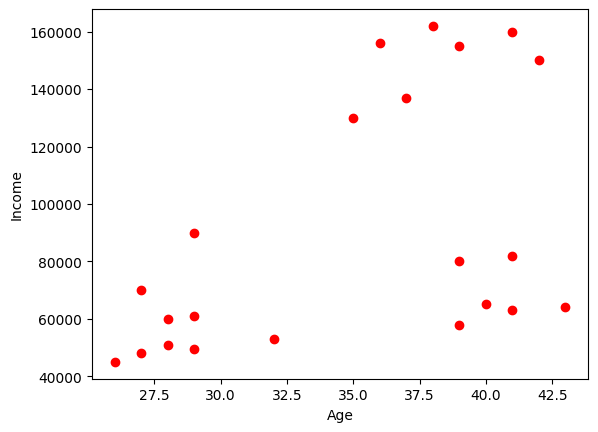

In [2]:
import matplotlib.pyplot as plt
plt.scatter(df.age,df.income,marker='o',color='red')
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
km=KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [8]:
y_predicted=km.fit_predict(df[['age','income']])
y_predicted

array([0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [9]:
df['cluster']=y_predicted
df

,name,age,income,cluster
0,Rob,27,70000,0
1,Micheal,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Gautham,39,155000,1
6,David,41,160000,1
7,Amdrea,38,162000,1
8,Brad,36,156000,1
9,Angelia,35,130000,1


In [10]:
df0=df[df.cluster==0]
df1=df[df.cluster==1]
df2=df[df.cluster==2]

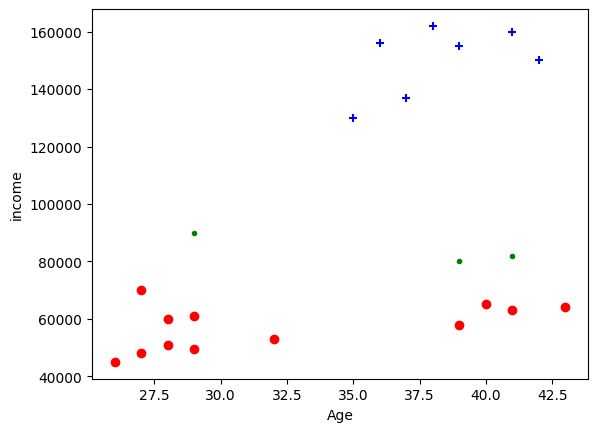

In [13]:
plt.scatter(df0.age,df0.income,marker='o',color='red')
plt.scatter(df1.age,df1.income,marker='+',color='blue')
plt.scatter(df2.age,df2.income,marker='.',color='green')
plt.xlabel('Age')
plt.ylabel('income')
plt.show()

In [15]:
scaler=MinMaxScaler()
scaler.fit(df[['income']])
df['income'] = scaler.transform(df[['income']])
df

,name,age,income,cluster
0,Rob,27,0.213675,0
1,Micheal,29,0.384615,2
2,Mohan,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1
5,Gautham,39,0.940171,1
6,David,41,0.982906,1
7,Amdrea,38,1.000000,1
8,Brad,36,0.948718,1
9,Angelia,35,0.726496,1


In [21]:
scaler.fit(df[['age']])
df['age'] = scaler.transform(df[['age']])
df

,name,age,income,cluster
0,Rob,0.058824,0.213675,0
1,Micheal,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautham,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Amdrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelia,0.529412,0.726496,1


In [22]:
km=KMeans(n_clusters=3)
km
y_predicted=km.fit_predict(df[['age','income']])
y_predicted
df['cluter']=y_predicted
df

,name,age,income,cluster,cluter
0,Rob,0.058824,0.213675,0,1
1,Micheal,0.176471,0.384615,2,1
2,Mohan,0.176471,0.136752,0,1
3,Ismail,0.117647,0.128205,0,1
4,Kory,0.941176,0.897436,1,0
5,Gautham,0.764706,0.940171,1,0
6,David,0.882353,0.982906,1,0
7,Amdrea,0.705882,1.000000,1,0
8,Brad,0.588235,0.948718,1,0
9,Angelia,0.529412,0.726496,1,0


In [23]:
df0=df[df.cluter==0]
df1=df[df.cluter==1]
df2=df[df.cluter==2]

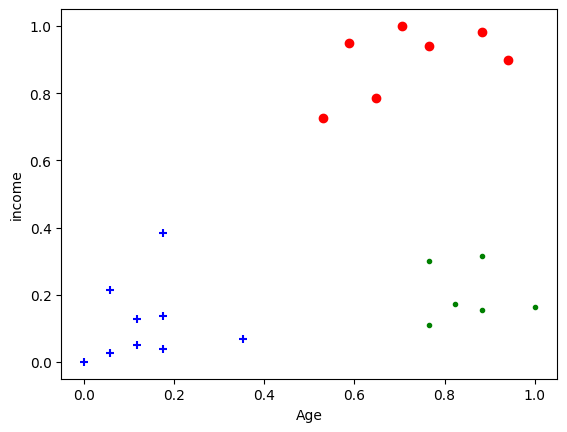

In [24]:
plt.scatter(df0.age,df0.income,marker='o',color='red')
plt.scatter(df1.age,df1.income,marker='+',color='blue')
plt.scatter(df2.age,df2.income,marker='.',color='green')
plt.xlabel('Age')
plt.ylabel('income')
plt.show()

In [25]:
k_range=range(1,10)
sse=[]
for i in k_range:
    km=KMeans(n_clusters=i)
    km.fit(df[['age','income']])
    sse.append(km.inertia_)

In [26]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.34910470944195654,
 0.30713504184752916,
 0.24387536901677193,
 0.22117646932437113,
 0.1327661931978319,
 0.11304517838728054]

Text(0, 0.5, 'Sum of Squared error')

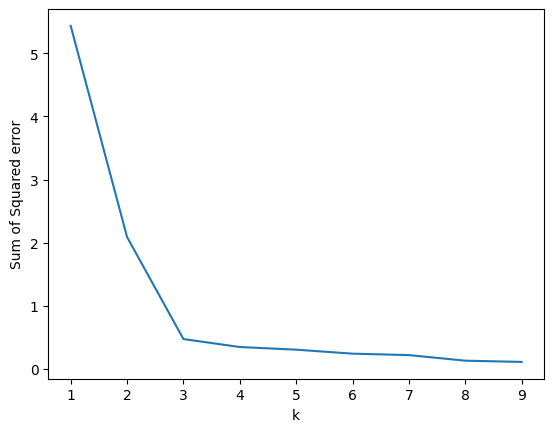

In [27]:
plt.plot(k_range,sse)
plt.xlabel('k')
plt.ylabel('Sum of Squared error')

In [ ]:
#Elbow point =3